## 1. Introducción

Sebastian Maldonado y Juan Roncancio, Laboratorio 4

## 2. Importación de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.model_selection import ParameterGrid
import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

## 3. Carga de datos - Exploración y Limpieza de datos

In [2]:
df = pd.read_csv('Datos_VuelaAlpes.csv')
print("Forma del dataset:", df.shape)
display(df.head(3))
display(df.dtypes.to_frame("dtype").T)
nulos = df.isna().sum().sort_values(ascending=False)
nulos = nulos[nulos > 0]
print("Columnas con nulos:", len(nulos))
display(nulos)
duplicados = df.duplicated().sum()
print("Filas duplicadas:", duplicados)

Forma del dataset: (10000, 23)


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,119496,Male,Loyal Customer,29,Business travel,Business,814,3,3,3,...,4,4,4,2,5,4,4,4,9,6.0
1,60419,Male,Loyal Customer,54,Business travel,Business,2913,4,4,4,...,4,4,4,4,4,4,4,4,26,9.0
2,9671,Male,Loyal Customer,52,Business travel,Eco,277,4,5,5,...,4,4,4,4,4,3,4,4,68,42.0


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
dtype,int64,str,str,int64,str,str,int64,int64,int64,int64,...,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64


Columnas con nulos: 1


Arrival Delay in Minutes    25
dtype: int64

Filas duplicadas: 0


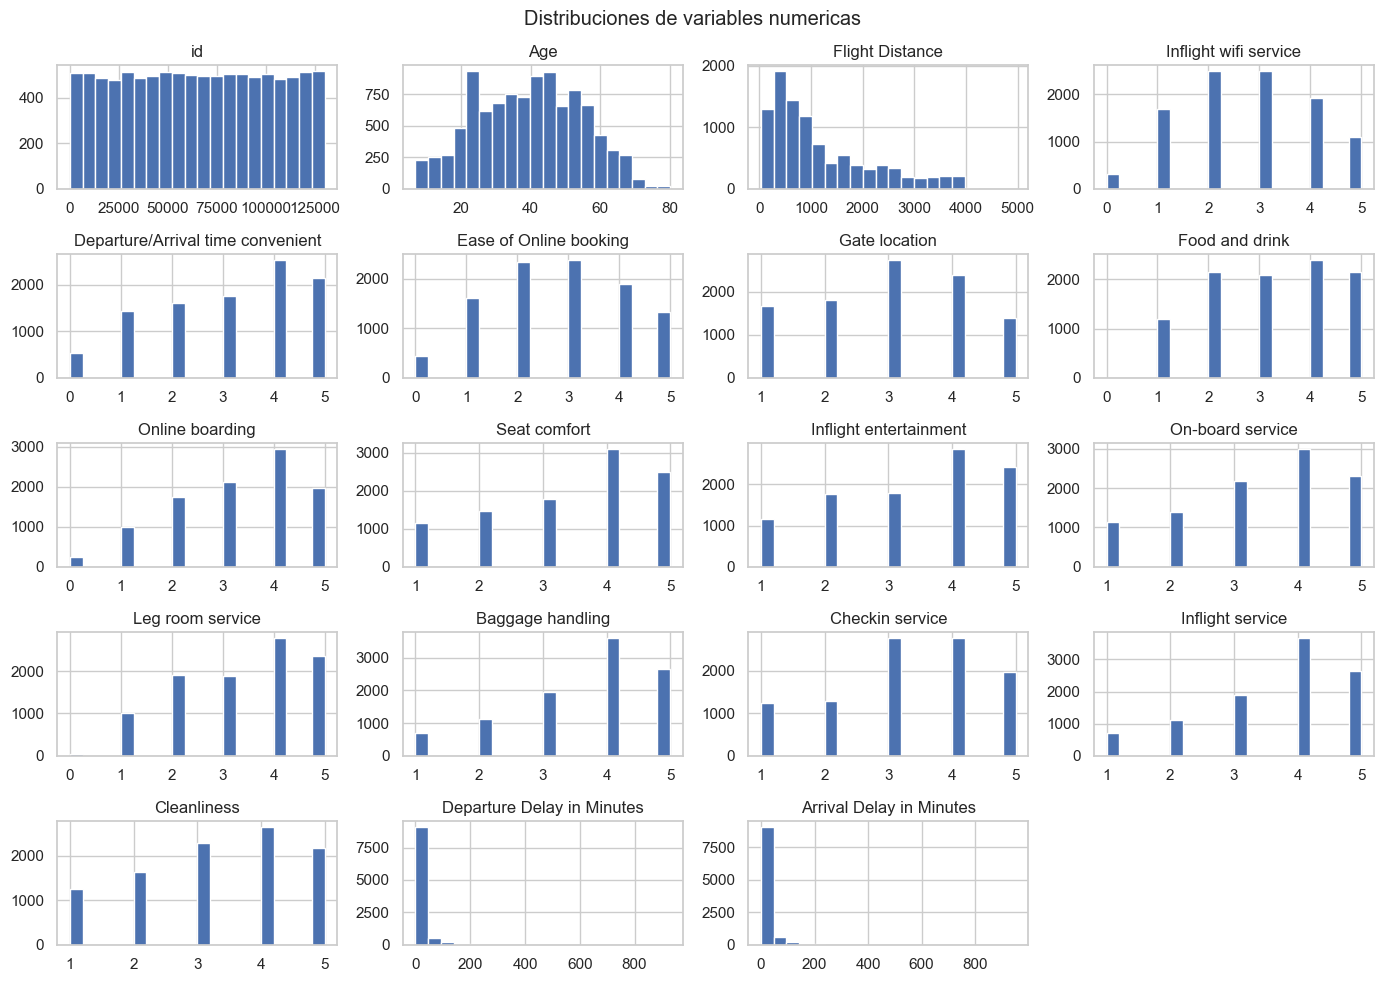

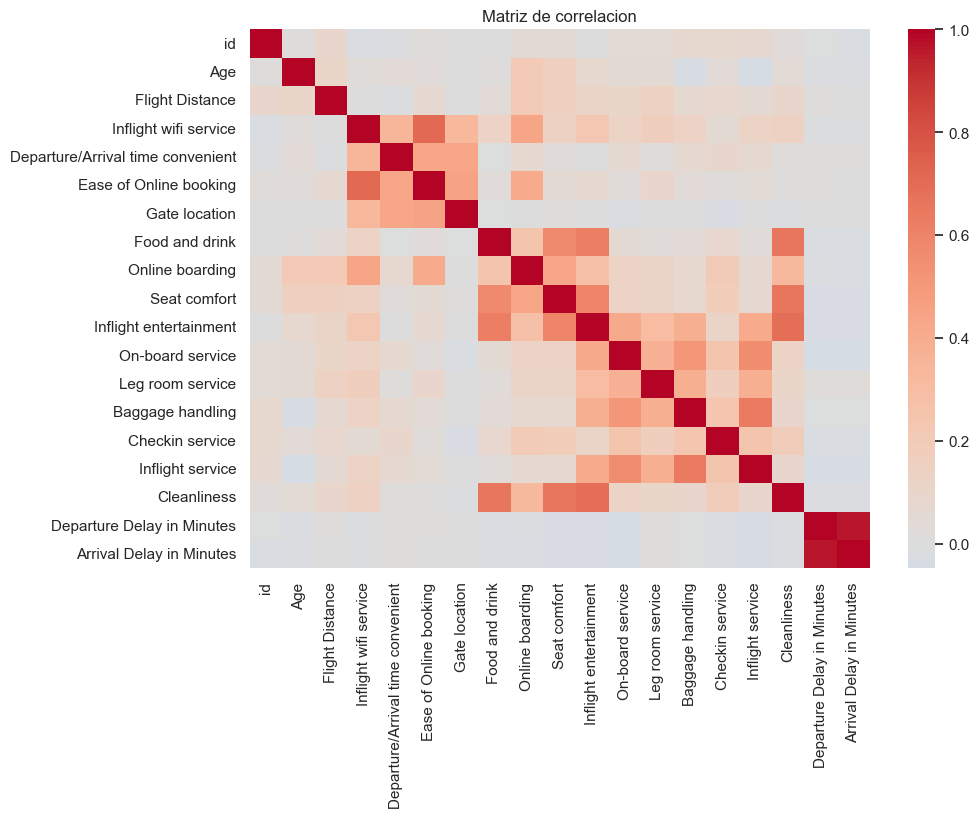

In [3]:
num_cols_raw = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if len(num_cols_raw) > 0:
    df[num_cols_raw].hist(bins=20, figsize=(14, 10))
    plt.suptitle("Distribuciones de variables numericas")
    plt.tight_layout()
    plt.show()

    corr = df[num_cols_raw].corr(numeric_only=True)
    plt.figure(figsize=(10, 7))
    sns.heatmap(corr, cmap='coolwarm', center=0)
    plt.title("Matriz de correlacion")
    plt.show()

### 4. Decisiones de limpieza 

- Eliminar columnas con demasiados nulos (si existen).
- Imputar nulos en variables numéricas con mediana.
- Imputar nulos en categóricas con la moda o una categoría 'Desconocido'.
- Convertir variables categóricas a one-hot encoding.
- Escalar variables numéricas con StandardScaler.

In [4]:
df_clean = df.copy()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.to_list()
cat_cols = df_clean.select_dtypes(include=['object', 'category', 'bool']).columns.to_list()

drop_cols = ['id']
df_clean.drop(columns=drop_cols, inplace=True, errors='ignore')

num_cols = [c for c in num_cols if c not in drop_cols]
cat_cols = [c for c in cat_cols if c not in drop_cols]

for c in num_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())
for c in cat_cols:
    df_clean[c] = df_clean[c].fillna('Desconocido')

df_clean.shape

(10000, 22)

### Justificación de limpieza y preparación

A partir de la exploración inicial se identificó que el conjunto de datos tiene 10000 registros y 23 columnas. No se encontraron filas duplicadas, por lo que no fue necesario eliminar registros repetidos. También se observó que la única columna con valores faltantes fue `Arrival Delay in Minutes`, con 25 valores nulos.

Para la preparación de los datos se tomaron las siguientes decisiones:

- Se eliminó la columna `id`, porque corresponde a un identificador del registro y no aporta información real sobre el comportamiento, experiencia o características del pasajero. Mantenerla podría distorsionar las distancias usadas por los algoritmos de agrupación.
- Los valores faltantes numéricos se imputaron con la mediana, porque esta medida es más robusta frente a valores extremos que el promedio.
- Las variables categóricas se trataron mediante codificación One-Hot, porque los algoritmos de agrupación requieren variables numéricas para calcular distancias o similitudes.
- Las variables numéricas se escalaron con `StandardScaler`, ya que KMeans, AgglomerativeClustering y DBSCAN son sensibles a la escala de las variables.
- Se mantuvieron variables demográficas, características del vuelo y calificaciones de servicio porque son relevantes para caracterizar perfiles de pasajeros y relacionarlos con decisiones de innovación, calidad y capacitación.

### Análisis de calidad de datos

Se revisó la calidad del conjunto de datos desde varias dimensiones. En completitud, se encontró que la única variable con valores faltantes fue `Arrival Delay in Minutes`, con 25 registros nulos sobre 10000, por lo que el porcentaje de ausencia es bajo. En unicidad, no se encontraron filas duplicadas, de modo que cada observación puede tratarse como un registro independiente de la experiencia de vuelo. En consistencia y validez, las variables numéricas se mantienen dentro de rangos esperados para el contexto del problema y las variables categóricas principales, como tipo de cliente, tipo de viaje y clase, mantienen categorías coherentes con el diccionario de datos.

También se revisaron distribuciones y relaciones relevantes para una tarea de agrupación. Las variables de calificación presentan escalas ordinales comparables, mientras que edad, distancia de vuelo y demoras tienen magnitudes distintas y distribuciones más dispersas. Los posibles valores atípicos, especialmente en distancias y retrasos, no se eliminan de forma automática porque pueden representar experiencias reales de vuelo que ayudan a diferenciar segmentos. Por esta razón, la preparación no se limita a imputar nulos: también se eliminan identificadores sin valor predictivo para segmentación, se codifican variables categóricas y se escalan variables numéricas. Estas decisiones evitan que variables con mayor escala dominen las distancias usadas por los algoritmos de agrupación y hacen que el proceso sea reproducible mediante un pipeline.

## 5. Pipeline de preprocesamiento

Se construyó un `ColumnTransformer` para integrar el preprocesamiento de variables numéricas y categóricas en un flujo reproducible. Las variables numéricas se escalaron con `StandardScaler` y las variables categóricas se transformaron con `OneHotEncoder`.

Este preprocesamiento se utiliza antes de aplicar los tres algoritmos de agrupación. De esta manera, todos los modelos reciben la misma matriz transformada, lo que permite comparar los resultados de forma justa y ordenada.

### Reproducibilidad del preprocesamiento

El flujo de preparación se mantiene reproducible porque las decisiones de limpieza y transformación quedan explícitas en el notebook. Primero se imputan los nulos numéricos con la mediana y los nulos categóricos con la categoría `Desconocido`. Luego, con `ColumnTransformer` y `Pipeline`, se aplica `StandardScaler` a las variables numéricas y `OneHotEncoder` a las variables categóricas. Esto es especialmente importante en agrupación, porque KMeans, Agglomerative Clustering y DBSCAN dependen de distancias: si las variables no se escalan, atributos como distancia o demoras podrían dominar artificialmente la formación de grupos.

In [5]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

## 6. Definición de modelos y búsqueda de hiperparámetros

Se aplican tres algoritmos: KMeans, AgglomerativeClustering y DBSCAN.
Usamos la métrica `silhouette_score` (intrínseca) para comparar.

### Descripción, supuestos y pertinencia de los algoritmos

**KMeans.** Este algoritmo particiona las observaciones en `k` grupos minimizando la distancia de cada registro al centroide de su cluster. Su principal supuesto es que los grupos pueden representarse de forma razonable mediante centroides y que las distancias entre registros son informativas. Por eso requiere escalamiento previo y una selección explícita del número de clusters. Es pertinente para VuelaAlpes porque permite construir segmentos compactos y fáciles de interpretar para apoyar decisiones de servicio, experiencia y priorización de clientes.

**Agglomerative Clustering.** Es un método jerárquico que inicia con cada observación como un grupo independiente y luego fusiona grupos según su cercanía. No depende de centroides, pero sí de una medida de distancia y de una regla de enlace. Es útil como contraste porque permite evaluar si la estructura de los datos aparece de forma similar a KMeans cuando se usa una lógica de agrupación distinta. Su restricción principal es que puede ser más costoso computacionalmente y también requiere definir o seleccionar el número final de grupos.

**DBSCAN.** Agrupa observaciones según densidad, usando los parámetros `eps` y `min_samples`. Su ventaja es que puede identificar ruido y no exige fijar previamente el número de clusters. Sin embargo, es sensible a la escala de las variables y a la elección de `eps`; si los datos no presentan regiones densas claras, puede clasificar demasiados registros como ruido. En este caso es pertinente evaluarlo porque puede revelar pasajeros atípicos o patrones densos, pero su utilidad final depende de que los clusters resultantes sean estables e interpretables para VuelaAlpes.

In [6]:
def silhouette_safe(X, labels):
    labels = np.array(labels)
    
    mask = labels != -1
    if mask.sum() < 3:
        return -1
    
    labels_valid = labels[mask]
    X_valid = X[mask]
    
    if len(np.unique(labels_valid)) < 2:
        return -1
    return silhouette_score(X_valid, labels_valid)

X_full = preprocessor.fit_transform(df_clean)
print("Shape matriz transformada: ", X_full.shape)

Shape matriz transformada:  (10000, 27)


## 6.1 KMeans — búsqueda simple

In [7]:
k_range = range(2, 7)
best_k = None
best_score = -1
results_kmeans = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k =km.fit_predict(X_full)
    score = silhouette_safe(X_full, labels_k)
    results_kmeans.append({'k':k, 'silhouette':score})
    if score>best_score:
        best_score = score
        best_k = k
best_k, best_score

(2, 0.14037435347551563)

## 6.2 Agglomerative — búsqueda simple

In [8]:
agg_range = range(2, 7)
best_agg = None
best_score_agg = -1
results_agg = []

for k in agg_range:
    ag = AgglomerativeClustering(n_clusters=k)
    labels_a = ag.fit_predict(X_full)
    score = silhouette_safe(X_full, labels_a)
    results_agg.append({'k':k, 'silhouette':score})
    if score>best_score_agg:
        best_score_agg = score
        best_agg = k
best_agg, best_score_agg

(3, 0.11604088645969214)

## 6.3 DBSCAN — búsqueda de eps y min_samples (pequeña cuadrícula)

In [9]:
eps_list = [0.3, 0.5, 0.7, 1.0]
min_samples_list = [3, 5, 7]
results_dbscan = []
best_db = None
best_score_db = -1

for params in ParameterGrid({'eps':eps_list, 'min_samples':min_samples_list}):
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels_d = db.fit_predict(X_full)
    score = silhouette_safe(X_full, labels_d)
    results_dbscan.append({'eps':params['eps'], 'min_samples':params['min_samples'], 'silhouette':score})
    if score>best_score_db:
        best_score_db = score
        best_db = params
best_db, best_score_db

({'eps': 1.0, 'min_samples': 3}, 0.5048688514522929)

In [10]:
db_final = DBSCAN(eps=best_db["eps"], min_samples=best_db["min_samples"])
labels_db = db_final.fit_predict(X_full)

db_counts = pd.Series(labels_db).value_counts().sort_index()
display(db_counts)

porcentaje_ruido = (labels_db == -1).mean() * 100
print(f"Porcentaje de registros clasificados como ruido por DBSCAN: {porcentaje_ruido:.2f}%")


-1     9887
 0        3
 1        3
 2        3
 3        9
 4        4
 5        3
 6        4
 7        3
 8        3
 9        3
 10       3
 11       4
 12       3
 13       3
 14       3
 15       5
 16       3
 17       3
 18       3
 19       3
 20       4
 21       4
 22       3
 23       3
 24       4
 25       3
 26       3
 27       3
 28       3
 29       3
 30       3
 31       3
 32       3
Name: count, dtype: int64

Porcentaje de registros clasificados como ruido por DBSCAN: 98.87%


In [11]:
pipelines_modelos = {
    "KMeans": Pipeline(steps=[
        ("preprocesamiento", preprocessor),
        ("modelo", KMeans(n_clusters=best_k, random_state=42, n_init=10))
    ]),
    "Agglomerative": Pipeline(steps=[
        ("preprocesamiento", preprocessor),
        ("modelo", AgglomerativeClustering(n_clusters=best_agg))
    ]),
    "DBSCAN": Pipeline(steps=[
        ("preprocesamiento", preprocessor),
        ("modelo", DBSCAN(eps=best_db["eps"], min_samples=best_db["min_samples"]))
    ])
}

pipelines_modelos

{'KMeans': Pipeline(steps=[('preprocesamiento',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('scaler',
                                                                    StandardScaler())]),
                                                   ['Age', 'Flight Distance',
                                                    'Inflight wifi service',
                                                    'Departure/Arrival time '
                                                    'convenient',
                                                    'Ease of Online booking',
                                                    'Gate location',
                                                    'Food and drink',
                                                    'Online boarding',
                                                    'Seat comfort',
                                                    'Inflight entertainm

## 7. Comparación de resultados
### Construimos una tabla con los mejores resultados de cada algoritmo.

In [12]:
df_k = pd.DataFrame(results_kmeans)
df_agg = pd.DataFrame(results_agg)
df_db = pd.DataFrame(results_dbscan)

best_rows = []
best_rows.append({'alg': 'KMeans', 'param': f'n_clusters={best_k}', 'silhouette': best_score})
best_rows.append({'alg': 'Agglomerative', 'param': f'n_clusters={best_agg}', 'silhouette': best_score_agg})
best_rows.append({'alg': 'DBSCAN', 'param': f"eps={best_db['eps']}, min_samples={best_db['min_samples']}", 'silhouette': best_score_db})

tabla_comparativa = pd.DataFrame(best_rows).sort_values('silhouette', ascending=False).reset_index(drop=True)
display(tabla_comparativa)

,alg,param,silhouette
0,DBSCAN,"eps=1.0, min_samples=3",0.504869
1,KMeans,n_clusters=2,0.140374
2,Agglomerative,n_clusters=3,0.116041


### Tabla comparativa ampliada y selección del mejor modelo

| Modelo | Hiperparámetros seleccionados | Grupos generados | Silhouette | Interpretación para la selección |
|---|---:|---:|---:|---|
| DBSCAN | `eps=1.0`, `min_samples=3` | 33 clusters válidos + ruido | 0.504869 | Aunque obtiene la mayor silueta, clasifica el 98.87% de los registros como ruido. Por tanto, el resultado no es suficientemente estable ni accionable para segmentar clientes de VuelaAlpes. |
| KMeans | `n_clusters=2`, `random_state=42`, `n_init=10` | 2 clusters | 0.140374 | Tiene una silueta menor, pero produce grupos balanceados, interpretables y coherentes con variables demográficas, tipo de viaje, clase y calificaciones del servicio. |
| Agglomerative Clustering | `n_clusters=3` | 3 clusters | 0.116041 | Permite contrastar la estructura de grupos desde una lógica jerárquica, pero separa los datos con menor calidad cuantitativa e interpretabilidad frente a KMeans. |

La selección del modelo final no se basa únicamente en la métrica de silueta. Para una tarea no supervisada orientada a decisiones de negocio, también se consideran la estabilidad, el tamaño de los segmentos, la facilidad de interpretación y la utilidad para diseñar acciones. Bajo estos criterios, KMeans se selecciona como mejor modelo: produce dos segmentos claros, con tamaños razonables y diferencias interpretables en satisfacción, distancia de vuelo, tipo de cliente, clase y experiencia de servicio.

## 8. Interpretación cualitativa de los clusters

In [13]:
modelo_final_nombre = "KMeans"
modelo_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)

labels = modelo_final.fit_predict(X_full)

df_result = df_clean.copy()
df_result['cluster'] = labels
df_result['cluster'] = df_result['cluster'].astype(int)

print("Modelo final seleccionado para interpretación:", modelo_final_nombre)
print("Número de clusters:", best_k)
display(df_result['cluster'].value_counts().sort_index())

Modelo final seleccionado para interpretación: KMeans
Número de clusters: 2


cluster
0    4573
1    5427
Name: count, dtype: int64

### Selección del modelo final

La tabla comparativa muestra que DBSCAN obtuvo el mayor coeficiente de silueta. Sin embargo, al revisar la distribución de clusters se observó que este algoritmo clasificó la gran mayoría de registros como ruido (`cluster = -1`) y generó grupos demasiado pequeños. Por esta razón, aunque DBSCAN fue el mejor desde una lectura estrictamente cuantitativa de la silueta, no se considera el modelo más útil para el objetivo de VuelaAlpes.

Para la interpretación cualitativa y la toma de decisiones de negocio se seleccionó **KMeans** como modelo final. Esta decisión se justifica porque KMeans asigna todos los pasajeros a grupos, permite caracterizar segmentos más amplios y facilita traducir los resultados en acciones para innovación, capacitación de la tripulación y mejora de calidad del servicio.

En conclusión, se diferencia entre el mejor resultado numérico y el mejor resultado accionable para la organización. DBSCAN obtuvo la mejor métrica, pero KMeans ofrece una segmentación más interpretable y útil para VuelaAlpes.

## 8.1 Perfilado de clusters — resumen por cluster

In [14]:
print("Tamano de cada cluster:")
display(df_result['cluster'].value_counts().sort_index())

if len(num_cols) > 0:
    print("\nPromedio de variables numericas por cluster:")
    display(df_result.groupby('cluster')[num_cols].mean().round(2))

if len(cat_cols) > 0:
    print("\nModa de variables categoricas por cluster:")
    perfil_cat = df_result.groupby('cluster')[cat_cols].agg(
        lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan
    )
    display(perfil_cat)

Tamano de cada cluster:


cluster
0    4573
1    5427
Name: count, dtype: int64


Promedio de variables numericas por cluster:


,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
cluster,,,,,,,,,,,,,,,,,,
0,37.47,993.4,2.27,2.95,2.48,2.96,2.44,2.57,2.56,2.27,2.79,2.83,3.12,2.90,3.12,2.39,16.85,17.07
1,41.03,1366.8,3.12,3.18,3.00,3.04,3.87,3.79,4.17,4.28,3.90,3.78,4.07,3.62,4.09,4.03,13.18,13.58



Moda de variables categoricas por cluster:


,Gender,Customer Type,Type of Travel,Class
cluster,,,,
0,Female,Loyal Customer,Business travel,Eco
1,Female,Loyal Customer,Business travel,Business


### Interpretación del modelo final KMeans

El modelo final seleccionado para interpretación fue KMeans. Este modelo permite dividir a los pasajeros en grupos generales con características similares y, a diferencia de DBSCAN, asigna todos los registros a un segmento.

La interpretación de los clusters se realiza comparando los promedios de las variables numéricas y las modas de las variables categóricas. Las variables más relevantes para el análisis son la edad, la distancia del vuelo, los retrasos, el tipo de viaje, la clase y las calificaciones de servicios como comodidad del asiento, entretenimiento, limpieza, servicio a bordo, manejo de equipaje y check-in.

Estos grupos pueden ayudar a VuelaAlpes a identificar perfiles de pasajeros con necesidades diferentes. Por ejemplo, algunos segmentos pueden estar más asociados con viajes de negocio y mejores calificaciones del servicio, mientras que otros pueden reflejar experiencias afectadas por retrasos o menores niveles de satisfacción. Esta información es útil para diseñar acciones diferenciadas de mejora en servicio, capacitación e innovación.

### Interpretación específica de los segmentos KMeans

El modelo KMeans genera dos segmentos con tamaños relativamente balanceados. El **cluster 0** agrupa 4573 registros y presenta una edad promedio menor, una distancia promedio de vuelo más baja y calificaciones inferiores en servicios como wifi, comida, abordaje en línea, comodidad, entretenimiento y limpieza. Además, su clase más frecuente es `Eco`. Este grupo puede interpretarse como un segmento con experiencia de servicio más vulnerable, donde VuelaAlpes podría priorizar mejoras operativas, capacitación de tripulación y acciones de calidad en puntos de contacto visibles para el cliente.

El **cluster 1** agrupa 5427 registros y tiene una edad promedio ligeramente mayor, vuelos de mayor distancia promedio y mejores calificaciones en la mayoría de atributos del servicio. Su clase más frecuente es `Business`, lo que sugiere un segmento de clientes con una experiencia más favorable y posiblemente mayor exposición a servicios diferenciados. Para VuelaAlpes, este grupo puede servir como referencia de buenas prácticas y como base para diseñar estrategias de retención, fidelización y transferencia de estándares de servicio hacia segmentos con menor satisfacción.

Esta interpretación evita tratar el problema como una clasificación supervisada: la variable de satisfacción se usa solo como apoyo posterior para entender la utilidad de los segmentos, no como etiqueta objetivo durante la formación de los grupos.

### Observación sobre DBSCAN

Aunque DBSCAN obtuvo el mayor coeficiente de silueta, su resultado debe interpretarse con cuidado. El modelo clasificó la mayoría de los registros como ruido (`cluster = -1`) y generó clusters con muy pocos pasajeros. Por esta razón, el resultado no es suficientemente accionable para VuelaAlpes, ya que no permite caracterizar segmentos amplios y útiles para tomar decisiones de negocio.

Esto demuestra que una métrica alta no siempre implica una mejor solución en problemas de agrupación. En este caso, DBSCAN separó muy bien unos pocos grupos pequeños, pero no logró segmentar adecuadamente a la mayoría de pasajeros. Por eso, para la evaluación cualitativa se decidió trabajar con KMeans como modelo final interpretable.

## 9. Visualización (PCA 2D)

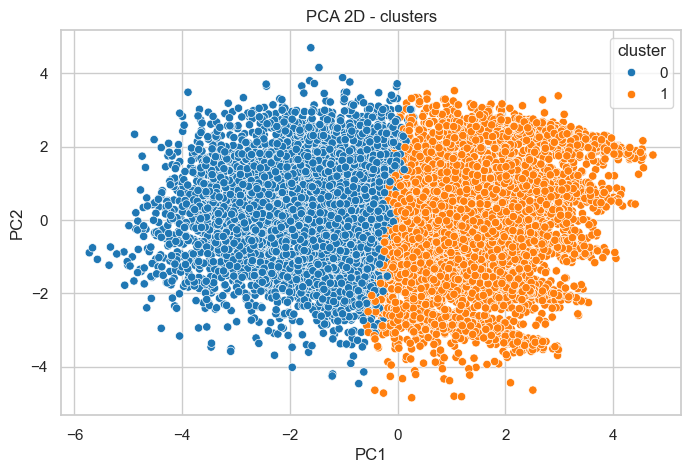

In [15]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_full)
vis_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
vis_df['cluster'] = labels
sns.scatterplot(data=vis_df, x='PC1', y='PC2', hue='cluster', palette='tab10')
plt.title('PCA 2D - clusters')
plt.show()

## 10. Respuestas al apartado de Análisis de resultados

### 1. ¿Qué restricciones tiene cada uno de los algoritmos seleccionados? ¿Cómo afectan estas restricciones la calidad de la solución obtenida?

**KMeans** asume que los grupos tienen una forma relativamente compacta y cercana a esférica. Además, es sensible a la escala de las variables y a valores extremos. Por eso fue necesario estandarizar las variables numéricas. Si los grupos reales de pasajeros no tienen una forma compacta, KMeans puede generar agrupaciones simples que no capturen completamente la estructura del problema.

**AgglomerativeClustering** depende de la métrica de distancia y del criterio de enlace utilizado. Además, puede ser costoso computacionalmente cuando el conjunto de datos es grande. Su ventaja es que permite encontrar estructuras jerárquicas, pero su calidad puede variar si las distancias entre pasajeros no reflejan bien diferencias reales de comportamiento.

**DBSCAN** depende fuertemente de los hiperparámetros `eps` y `min_samples`. Este algoritmo puede detectar ruido y grupos de forma irregular, pero en este caso generó una gran cantidad de pasajeros clasificados como ruido. Aunque obtuvo el mayor valor de silueta, esa métrica fue engañosa porque el modelo dejó por fuera a casi todos los registros. Por lo tanto, DBSCAN no resulta adecuado como solución principal para segmentar pasajeros en este caso.

### 2. ¿Qué criterios son importantes para la selección del algoritmo?

Los criterios más importantes fueron:

- El coeficiente de silueta, porque permite medir qué tan separados y cohesionados están los grupos.
- La proporción de registros asignados a clusters válidos, porque un modelo que clasifica la mayoría de pasajeros como ruido no es útil para la organización.
- La interpretabilidad de los grupos, ya que VuelaAlpes necesita entender perfiles de pasajeros para tomar decisiones.
- La estabilidad frente a cambios de hiperparámetros.
- La utilidad del resultado para los objetivos de negocio: innovación, capacitación de la tripulación y mejora de calidad del servicio.

### 3. ¿Cómo medir la calidad del modelo construido? ¿Cómo saber que el modelo construido tiene una buena calidad?

La calidad se midió cuantitativamente usando el coeficiente de silueta. Un valor más alto indica que los registros dentro de un mismo grupo son parecidos entre sí y diferentes frente a registros de otros grupos.

Sin embargo, en clustering no basta con mirar una sola métrica. También se debe revisar si los clusters tienen tamaños razonables, si no hay demasiados datos marcados como ruido y si los perfiles obtenidos tienen sentido para el negocio. Un modelo de buena calidad debe producir grupos interpretables, diferenciables y útiles para tomar decisiones.

### 4. ¿Cómo varía la calidad de la solución obtenida si se aplican diferentes algoritmos?

Los resultados muestran que la calidad cambia de forma importante según el algoritmo. DBSCAN obtuvo el mayor coeficiente de silueta, pero su resultado no fue adecuado desde el punto de vista del negocio porque clasificó casi todos los pasajeros como ruido y creó grupos muy pequeños. Esto evidencia que una métrica alta no siempre implica una solución útil.

KMeans y AgglomerativeClustering obtuvieron valores de silueta menores, pero generan segmentaciones más utilizables porque asignan todos los pasajeros a grupos. Por esa razón, para una solución orientada a VuelaAlpes resulta más razonable seleccionar un modelo que produzca grupos interpretables y accionables, aunque su métrica cuantitativa sea menor que la de DBSCAN.

### 5. ¿Cómo interpretar el resultado de la ejecución de los algoritmos de agrupación seleccionados?

Los clusters deben interpretarse como segmentos de pasajeros con características similares. Para analizarlos se revisaron variables como edad, distancia de vuelo, tipo de viaje, clase, retrasos y calificaciones de servicios como comodidad del asiento, entretenimiento, limpieza, atención a bordo, manejo de equipaje y servicio de check-in.

La interpretación debe enfocarse en identificar qué diferencia a cada grupo. Por ejemplo, un grupo puede representar pasajeros de negocio con mejores calificaciones del servicio, otro puede agrupar pasajeros con experiencias afectadas por retrasos o bajas calificaciones, y otro puede representar pasajeros con vuelos más largos o necesidades específicas de comodidad.

Estos grupos pueden ser útiles para VuelaAlpes porque permiten diseñar acciones diferenciadas: mejorar servicios críticos, priorizar capacitaciones de la tripulación, crear ofertas específicas por segmento y fortalecer la relación precio-calidad percibida por los pasajeros.

In [16]:
df_result.to_csv('resultados_clusters.csv', index=False)
pd.DataFrame(best_rows).to_csv('comparativa_modelos.csv', index=False)
print('Archivos guardados: resultados_clusters.csv, comparativa_modelos.csv')

Archivos guardados: resultados_clusters.csv, comparativa_modelos.csv


# Uso de herramientas de IA generativa

## Declaración de Uso

### Herramienta utilizada: Claude Haiku 4.5
### Tipos de Uso:

    - Se usó para revisar el cumplimiento del notebook al final del desarrollo de la solución en cuanto al enunciado del laboratorio.
    - Se usó para procesos de depuración conceptual como validación de decisiones de limpieza, preparación y modelamiento.
    - Se usó para apoyarnos en la explicación teórica para que nos fuera posible explicar cosas que no entendíamos como la comparación entre KMeans, AgglomerativeClustering y DBSCAN.
    - Se usó para apoyar nuestra interpretación y redacción del análisis de resultados de clustering.
    - Se usó para mejorar la redacción en cuanto al lenguaje técnico y en la corrección de la redacción de posibles conceptos parcialmente explicados en el análisis de resultados.

### Prompts Utilizados

    - Revisa el archivo "SebastianMaldonado - JuanRoncancio.ipynb" adjunto a este mensaje y dime si la solución está acorde, completa y cumple con el 100% del enunciado, no necesito que edites el archivo en absoluto, si consideras que hay que cambiar algo, explicame la razón y guíame paso a paso en la corrección.
    - Por favor revisa lo que escribí en la sección "3. Carga de datos - Exploración y Limpieza de datos" e indicame si las deciciones tomadas, y la ejecución de estas fue acertada. En la sección "4. Decisiones de limpieza" podrás ver explicitamente las decisiones que fueron tomadas.
    - Estoy un poco pérdido, finalmente elejí KMeans como modelo final, sin embargo, necesito que me ayudes a redactar la razón de esta selección si DBSCAN obtuvo mayor coeficiente de silueta.
    - ¿Cómo puedo interpretar cualitativamente los clusters obtenidos para el caso de negocio de VuelaAlpes?
    - Indicame detalladamente cuales deben ser los criterios y la información que debe contener el apartado de uso de IA para cumplir con el enunciado en un 100%.
    
### Análisis Crítico del Resultado

### ¿Qué partes del contenido generado fueron correctas y útiles?
    
    - La revisión final permitió estar seguros de que el notebook se ejecutaba correctamente en todas sus celdas y que cubría las actividades principales que se solicitaban en el enunciado.
    - Nos fue útil para la observación de DBSCAN, y aunque obtuvo el mayor coeficiente de silueta, no era el mejor modelo para el objetivo planteado.
    - Nos ayudó a mejorar la justificación de la selección de KMeans como modelo final.
    - Nos fue útil para identificar elementos faltantes dentro del entregable, como la exportación a HTML y la sección obligatoria del reporte de uso de IAG.
    - La redacción que nos sugirió la IA permitió fortalecer la interpretación cualitativa de los clusters y conectarla con los objetivos de VuelaAlpes.

### ¿Qué errores, impresiciones o limitaciones se identificaron?

    - Algunas recomendaciones iniciales eran muy genéricas y tuvimos que adaptarlas al contexto específico de VuelaAlpes.
    - La herramienta podía sugerir interpretaciones posibles, pero tuvimos que verificarlo con los valores reales obtenidos con el notebook.
    - La IA no reemplazo en absoluto la revisión manual de los resultados ni la decisión final sobre el modelo seleccionado.
    - Durante el desarrollo del laboratorio, fue necesario contrastar las sugerencias con la tabla comparativa, los tamaños de los clusters y la utilidad real del negocio.
    - Esto fue sobre todo importante, la métrica de silueta podría interpretarse de forma incompleta si no se revisaba también la proporción de registros clasificacos como ruido.

### ¿Qué decisiones técnicas fueron modificadas respecto a la respuesta de la IAG y por qué?

    - Decidimos no seleccionar DBSCAN como modelo final, a pesar de tener la mayor silueta, porque clasificó la mayoría de registros como ruido.
    - Mantuvimos KMeans como modelo final porque asigna todos los pasajeros a grupos y facilita mucho una interpretación útil.
    - Ajustamos la interpretación cualitativa para que no fuera muy genérica, sino conectada con variables concretas como clase, distancia del vuelo, retrasos y calificaciones del servicio.
    - Vaidamos manualmente que las celdas del notebook estuvieran completamente ejecutadas y no presentarán errores en absoluto.
    - Decidimos agregar evidencia explícita sobre la distribución de clusters de DBSCAN para respaldar mejor la decisión del modelo final.

### ¿Qué conceptos del curso permitieron evaluar o mejorar la respuesta generada?

    - Aprendizaje no supervisado: nos permitió entender que los clusters deben evaluarse tanto cualitativa como cuantitativamente.
    - Métricas intrínsecas de clustering: se utilizó el coeficiente de silueta para comparar los modelos mencionados.
    - Interpretabilidad de modelos: evaluamos si los clusters podían convertirse en acciones útiles para el negocio.
    - Preprocesamiento de datos: validamos la necesidad de escalar variables númericas y codificar variables categóricas.
    - CRISP-ML: revisamos que el notebook respetara una estructura que siguiera etapas de exploración, preparación, modelamiento, evaluación e interpretación.

### APORTES PROPIOS DEL ESTUDIANTE

### ¿Qué fue desarrollado, modificado o decidido por el estudiante?

    - Escritura e integración completa del notebook que se entregó.
    - Carga, exploración y limpieza del conjuntos de datos.
    - Construcción del preprocesamiento con escalamiento y ONeHotEncoder.
    - Implementación de tres algoritmos de agrupación: KMeans, AgglomerativeClustering y DBSCAN. 
    - Búsqueda, prueba y error de hiperparámetros para los modelos que fueron seleccionados.
    - Construcción de la tabla comparativa con los resultados cuantitativos.
    - Selección de KMeans como modelo final por críterios de interpretabilidad y utilidad para negocio.
    - Interpretación de los clusters en relación con los objetivos de innovación, calidad y capacitación de VuelaAlpes.

### ¿Qué ajustes se realizaron sobre el código o la explicación original?

    - Reforzamos la justificación de limpieza y preparación de los datos.
    - Agregamos una explicación más clara sobre el por qué el identificador no debía usarse para clustering.
    - Mejoramos la explicación de la diferencia entre el mejor modelo cuantitativo y el modelo más útil para la organización.
    - Conectamos los perfiles de clusters con acciones concretas para VuelaAlpes.
    - Revisamos que las conclusiones respondieran a las preguntas del apartado de análisis de resultados.

### ¿Qué aprendizajes se obtuvieron del proceso?

    - Una métrica alta no necesariamente signfiica que sea una solución adecuada para el negocio.
    - En clustering es necesario combinar la evaluación cuantitativa con la interpretación cualitativa.
    - El modelo de DBSCAN puede producir buenos valores de silueta si deja muchos puntos como ruido, por lo que los resultados que este arroje se deben revisar cuidadosamente, no es del todo confiable.
    - El modelo de KMeans, aunque tiene una silueta menor, puede ser más útil cuando se necesitan segmentos amplios e interpretables.
    - Las herramientas de IAG son útiles para revisar, depurar y mejorar la redacción, pero las decisiones finales, al conllevar una responsabilidad importante, deben ser validadas con los resultados reales y los conceptos del curso.
